## Submission
### Design of this Notebook
Below we have code for "winning" scenario which demonstrates our methodology.

Below that a comparison of multiple scenarios that were run to analyze different KPIs. Nc files are shared in a zip and are referenced in this section.

### Given cells that required minimal or no modification - skip to next section for our model code

In [32]:
import pandas as pd
import numpy as np
import requests
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pvlib

In [33]:
# Given information:
node_lat = 54.6172
node_lon = 9.5776
node_alt = 0

distance12 = 53 #km

electricity_demand_multiplier = 0.54
heat_demand_multiplier = 0.43

In [34]:
# Create time series with hourly resolution for the given period
year = 2009
month = 2
times = pd.date_range(start='2009-02-01', end='2009-02-28 23:59:59', freq='h', tz='Europe/Amsterdam')

In [35]:
# Function to import climate data from JRC - DO NOT CHANGE

def import_jrc_climate_data(lon: float, lat: float, year: int | str, alt: float) -> dict:
    """
    Reads in climate data for a full year from `JRC PVGIS <https://re.jrc.ec.europa.eu/pvg_tools/en/>`_.

    :param float lon: longitude of node - the api will read data for this location
    :param float lat: latitude of node - the api will read data for this location
    :param int year: optional, needs to be in range of data available. If nothing is specified, a typical year \
    will be loaded
    :param float alt: altitude of location specified
    :return: dict containing information on the location (altitude, longitude, latitude and a dataframe \
    containing climate data (ghi = global horizontal irradiance, dni = direct normal irradiance, \
    dhi = diffuse horizontal irradiance, rh = relative humidity, temp_air = air temperature, ws = wind speed at \
    specified hight. Wind speed is returned as a dict for different heights.
    :rtype: dict
    """

    # Specify year import, lon, lat
    parameters = {"lon": lon, "lat": lat, "year": year, "outputformat": "json"}
    time_index = pd.date_range(
        start=str(year) + "-01-01 00:00", end=str(year) + "-12-31 23:00", freq="1h"
    )

    # Get data from JRC dataset
    answer = dict()
    print("Importing Climate Data...")
    response = requests.get("https://re.jrc.ec.europa.eu/api/tmy?", params=parameters)
    if response.status_code == 200:
        print("Importing Climate Data successful")
    else:
        raise Exception(response)
    data = response.json()
    climate_data = data["outputs"]["tmy_hourly"]

    # Compile return dict
    answer["longitude"] = lon
    answer["latitude"] = lat
    answer["altitude"] = alt

    ghi = []
    dni = []
    dhi = []
    rh = []
    temp_air = []
    wind_speed = dict()
    wind_speed["10"] = []

    for t_interval in climate_data:
        ghi.append(t_interval["G(h)"])
        dni.append(t_interval["Gb(n)"])
        dhi.append(t_interval["Gd(h)"])
        rh.append(t_interval["RH"])
        temp_air.append(t_interval["T2m"])
        wind_speed["10"].append(t_interval["WS10m"])

    answer["dataframe"] = pd.DataFrame(
        np.array([ghi, dni, dhi, temp_air, rh]).T,
        columns=["ghi", "dni", "dhi", "temp_air", "rh"],
        index=time_index,
    )
    for ws in wind_speed:
        answer["dataframe"]["ws" + str(ws)] = wind_speed[ws]

    return answer

In [36]:
# Import climate data

climate_data = import_jrc_climate_data(node_lon, node_lat, year, node_alt)

Importing Climate Data...
Importing Climate Data successful


In [37]:
# Create wind turbine power curve function - DO NOT CHANGE
name = "WindTurbine_Onshore_4000"
wt_data_path = 'data/WT_data.csv'
wt_data_full = pd.read_csv(wt_data_path, delimiter=";")
# match WT with data
wt_data = wt_data_full[wt_data_full["TurbineName"] == name]
hubheight = 120

# Make power curve
rated_capacity = wt_data.iloc[0]["RatedPowerkW"]
wind_speed = np.linspace(0, 35, 71)
power_output = wt_data.iloc[:, 13:84]
power_output = power_output.to_numpy()

f = interp1d(wind_speed, power_output)

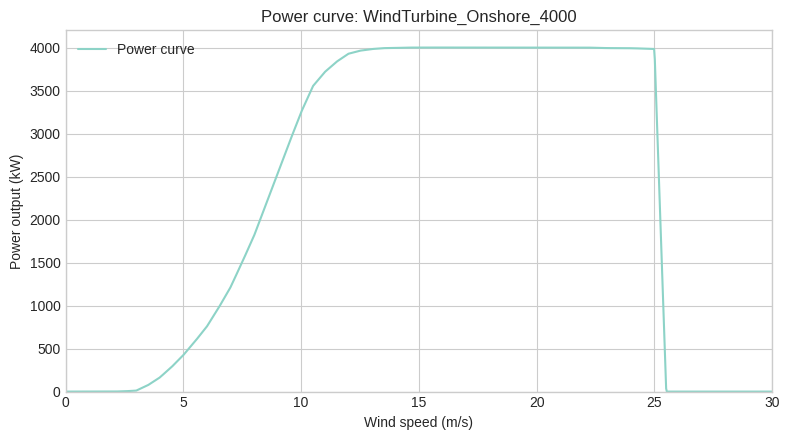

In [38]:
# Vizualize power curve

x_plot = np.linspace(0, 30, 1000)
y_plot = f(x_plot).ravel()

plt.figure(figsize=(8, 4.5))
plt.plot(x_plot, y_plot, label="Power curve")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power output (kW)")
plt.title(f"Power curve: {name}")
plt.legend()
plt.grid(True)
plt.xlim(0, 30)
plt.ylim(0, max(float(rated_capacity) * 1.05, power_output.max() * 1.05))
plt.tight_layout()
plt.show()

In [39]:
# Weather data - DO NOT CHANGE
df = climate_data['dataframe']

if "ws100" in df.columns:
    ws = df["ws100"]
    ws_height = 100
else:
    ws = df["ws10"]
    ws_height = 10

alpha = 1/7

if hubheight > 0:
    ws = ws * (hubheight / ws_height) ** alpha

In [40]:
# defining pv data - DO NOT CHANGE

pv_system_data = dict()
pv_system_data["tilt"] = 18
pv_system_data["surface_azimuth"] = 180
pv_system_data["module_name"] = "SunPower_SPR_X20_327"
pv_system_data["inverter_eff"] = 0.96

inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

In [41]:
# Fitting pv system - DO NOT CHANGE
module_database = pvlib.pvsystem.retrieve_sam("CECMod")
module = module_database[pv_system_data["module_name"]]

temperature_model_parameters = (
    pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS["sapm"][
        "open_rack_glass_glass"
    ]
)

# Create PV model chain
inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

system = pvlib.pvsystem.PVSystem(
    surface_tilt=pv_system_data["tilt"],
    surface_azimuth=pv_system_data["surface_azimuth"],
    module_parameters=module,
    inverter_parameters=inverter_parameters,
    temperature_model_parameters=temperature_model_parameters,
)

# Get location
tz = 'Europe/Amsterdam'

location = pvlib.location.Location(node_lat, node_lon, tz=tz, altitude=node_alt)

pv_model = pvlib.modelchain.ModelChain(
    system, location, spectral_model="no_loss", aoi_model="physical"
)
peakpower = module.STC

In [42]:
# Electricity and Heat demand data
import calendar

skip = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

demand_data_path = 'data/demand_production.xlsx'
df_p1 = pd.read_excel(demand_data_path, sheet_name='Point1', header=1)

el_demand   = df_p1['Electricity [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
el_demand = el_demand * electricity_demand_multiplier

heat_demand = df_p1['Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
heat_demand = heat_demand * heat_demand_multiplier

# print(f"Total electricity demand: {el_demand.sum():.1f} MWh")
# print(f"Average hourly demand: {el_demand.mean():.1f} MW")
# print(f"Peak demand: {el_demand.max():.1f} MW")
# print(f"Hours in dataset: {len(el_demand)}")  # should be 672 for February 2009

In [43]:
# Energy production

# Hours to skip to reach the selected month
skip_hours = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

# wind capacity factor
capacity_factor_wind = f(np.clip(ws.values, 0, 35)) / 4000
capacity_factor_wind = pd.Series(
    np.asarray(capacity_factor_wind).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

# solar capacity factor
pv_model.run_model(df)
power = pv_model.results.ac.p_mp
capacity_factor_solar = power / peakpower

capacity_factor_solar = pd.Series(
    np.asarray(capacity_factor_solar).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

/home/krivero/anaconda3/envs/esi_final/lib/python3.13/site-packages/scipy/optimize/_chandrupatla.py:437: RuntimeWarning: invalid value encountered in divide
  C = A / (A + B)


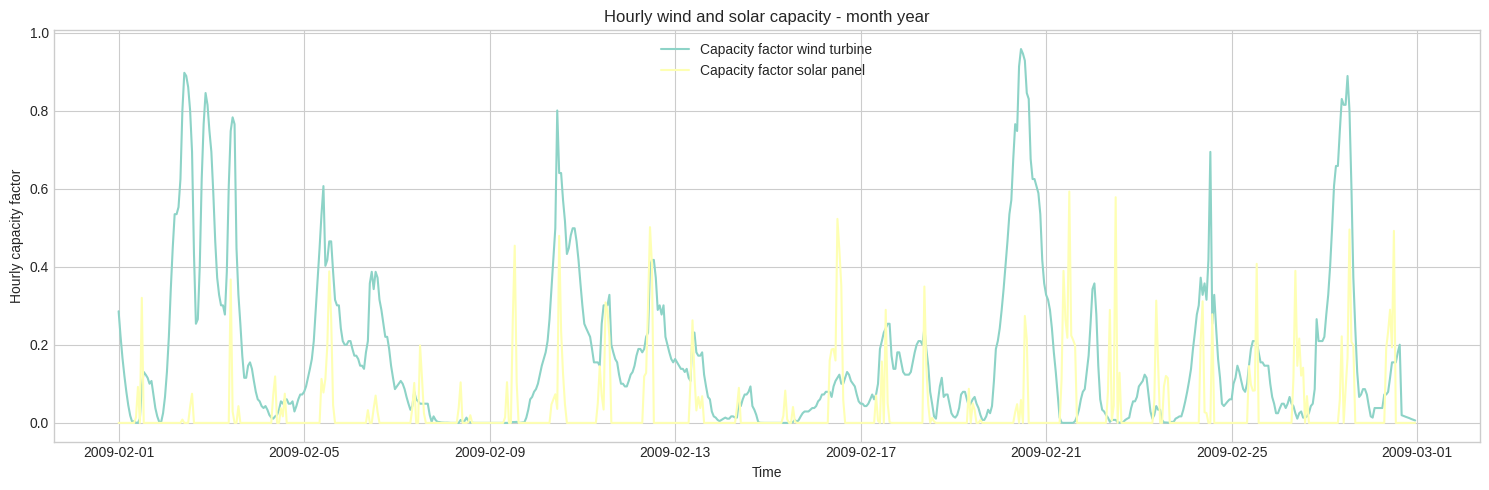

In [44]:
# Plot of capacity factors

plt.figure(figsize=(15, 5))

plt.plot(capacity_factor_wind.index, capacity_factor_wind, label='Capacity factor wind turbine')
plt.plot(capacity_factor_solar.index, capacity_factor_solar, label='Capacity factor solar panel')

plt.xlabel('Time')
plt.ylabel('Hourly capacity factor')
plt.title('Hourly wind and solar capacity - month year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [45]:
# Obtaining techno-economic data

tech_eco_data_path = 'data/technoeconomic_data.xlsx'
tech_eco_data = pd.read_excel(tech_eco_data_path, sheet_name='Data', header=2)

def get_value(df, component, data_type):
    mask = (df['component'] == component) & (df['parameter'] == data_type)
    result = df.loc[mask, 'value']
    if len(result) == 0:
        raise ValueError(f"No data found for component='{component}', parameter='{data_type}'")
    return result.values[0]

# We give you the wind turbine techno-economic data import as example. Save all the relevant data with the same function
# !!Make sure to use the correct units!!

# Wind turbine
Wind_capex = get_value(tech_eco_data, 'Wind turbine', 'Investment cost')  # EUR/kW
Wind_lifetime = get_value(tech_eco_data, 'Wind turbine', 'Lifetime')  # year
Wind_opex = get_value(tech_eco_data, 'Wind turbine', 'Opex') / 100  # % capex/year

## Start of our model code
### Bring in additional techno-economic data

In [46]:
# grab additional techno-economic data
Solar_capex = get_value(tech_eco_data, 'Solar panel', 'Investment cost')  #EUR/kw
Solar_lifetime = get_value(tech_eco_data, 'Solar panel', 'Lifetime') # year
Solar_opex = get_value(tech_eco_data, 'Solar panel', 'Opex') / 100 # % capex/year math included
Electricity_cable_capex = get_value(tech_eco_data, 'Electricity cable', 'Investment cost') #EUR/kw/km
Electricity_cable_lifetime = get_value(tech_eco_data, 'Electricity cable', 'Lifetime') # year
Electricity_cable_fixed_opex = get_value(tech_eco_data, 'Electricity cable', 'Fixed Opex') / 100 # %capex/year
Electricity_cable_losses = get_value(tech_eco_data, 'Electricity cable', 'Losses') / 100 # % per 100km

# relevant for part 2
# Hydrogen_pipeline_capex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Investment cost') # Eur/kw/km
# Hydrogen_pipeline_lifetime = get_value(tech_eco_data, 'Hydrogen pipeline', 'Lifetime') # year
# Hydrogen_pipeline_fixed_opex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Fixed Opex') /100 # % capex/year
# Hydrogen_pipeline_losses = get_value(tech_eco_data, 'Hydrogen pipeline', 'Losses') /100 # % per 100km

Li_ion_battery_capex = get_value(tech_eco_data, 'Li-ion battery', 'Investment cost') # EUR/kWh
Li_ion_battery_lifetime = get_value(tech_eco_data, 'Li-ion battery', 'Lifetime') # year
Li_ion_battery_opex = get_value(tech_eco_data, 'Li-ion battery', 'Opex') / 100 # % capex/year
Li_ion_battery_charging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Charging efficiency') / 100 # % input energy
Li_ion_battery_discharging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Discharging efficiency') / 100 # % output energy
Li_ion_battery_self_discharge_coefficient = get_value(tech_eco_data, 'Li-ion battery', 'Self-discharge coefficient') / 100 # % per hour
Li_ion_battery_max_charging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max charging capacity') / 100 # % size of battery
Li_ion_battery_max_discharging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max discharging capacity') / 100 # % size of battery

# relevant for part 2
# Hydrogen_storage_tank_capex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Investment cost') # EUR/kWh
# Hydrogen_storage_tank_lifetime = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Lifetime') #year
# Hydrogen_storage_tank_opex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Opex') / 100 # % capex/year
# Hydrogen_storage_tank_charging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Charging efficiency') / 100 # % input energy
# Hydrogen_storage_tank_discharging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank','Discharging efficiency') # error in data this does not need division by 100 % output energy
# Hydrogen_storage_tank_self_discharge_coefficient = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Self-discharge coefficient') / 100# %/hour
# Hydrogen_storage_tank_max_charging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max charging capacity') / 100 # %/size
# Hydrogen_storage_tank_max_discharging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max discharging capacity') / 100 # %/size
# Hydrogen_storage_tank_max_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max capacity') # MW
#
# Heat_storage_high_temp_capex = get_value(tech_eco_data, 'Heat storage - High temp', 'Investment cost') # EUR/MWh
# Heat_storage_high_temp_lifetime = get_value(tech_eco_data, 'Heat storage - High temp', 'Lifetime') # year
# Heat_storage_high_temp_opex = get_value(tech_eco_data, 'Heat storage - High temp', 'Opex') / 100 # % capex/year
# Heat_storage_high_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp', 'Charging efficiency') / 100 # % input energy
# Heat_storage_high_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp','Discharging efficiency') / 100 # % output energy
# Heat_storage_high_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - High temp', 'Self-discharge coefficient') # % / hour
# Heat_storage_high_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max charging capacity') / 100 # % size
# Heat_storage_high_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max discharging capacity') / 100 # % size
#
# Heat_storage_low_temp_capex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Investment cost') # EUR/MWh
# Heat_storage_low_temp_lifetime = get_value(tech_eco_data, 'Heat storage - Low temp', 'Lifetime') # year
# Heat_storage_low_temp_opex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Opex') /100 # % capex/year
# Heat_storage_low_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp', 'Charging efficiency') / 100 # % input energy
# Heat_storage_low_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp','Discharging efficiency') / 100# % output energy
# Heat_storage_low_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - Low temp', 'Self-discharge coefficient') / 100 # % / hour
# Heat_storage_low_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max charging capacity') / 100 # % size
# Heat_storage_low_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max discharging capacity') / 100 # % size
#
# Heat_pump_coefficient_of_performance = get_value(tech_eco_data, 'Heat pump', 'COP') # no unit
# Hydrogen_boiler_efficiency = get_value(tech_eco_data, 'Hydrogen boiler', 'Efficiency') / 100 # % input energy
Operational_cost_lost_load_penalty = get_value(tech_eco_data, 'Operational cost', 'Lost load penalty') # EUR/MWh
Operational_cost_max_import_availability = get_value(tech_eco_data, 'Operational cost', 'Max import availability') # MWh
Operational_cost_electricity_import_cost = get_value(tech_eco_data, 'Operational cost', 'Electricity import cost') # EUR/MWh
# Operational_cost_hydrogen_market_price = get_value(tech_eco_data, 'Operational cost', 'Hydrogen market price') # EUR/MWh


In [47]:
## PyPSA Model for Scenario C (example)

In [48]:
# PYPSA Following 1 Node Example
# https://docs.pypsa.org/latest/examples/capacity-expansion-planning-single-node/#model-initialisation
import pandas as pd
import pypsa
from pypsa.costs import annuity
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# data prep and variables
r = 0.05

# Battery parameters
p_nom_guess = 10  # MW, initial guess
# battery_energy_capacity = 25  # MWh, from your Li-ion spec
# battery_max_hours = battery_energy_capacity / p_nom_guess
eta_charge = Li_ion_battery_charging_efficiency # eta is efficiency
eta_discharge = Li_ion_battery_discharging_efficiency
max_charge_pu = Li_ion_battery_max_charging_capacity

# annualize the CAPEX
annualized_capex_wind = (Wind_capex*1000) * annuity(r, Wind_lifetime)
annualized_capex_solar = (Solar_capex*1000) * annuity(r, Solar_lifetime)
# annualized_capex_wind_manual = 80600 # eur/MW/y
# annualized_capex_solar_manual = 34200 # eur/MW/y
max_hours_bat = 4 #
annualized_capex_battery = (Li_ion_battery_capex*1000) * max_hours_bat * annuity(r, Li_ion_battery_lifetime) #eur/Mwh * h * annuity = eur/MW
annualized_capex_transmission = (Electricity_cable_capex*1000) * distance12 * annuity(r, Electricity_cable_lifetime) # Eur/kw/km * 1000 * km

#annualize the OPEX
annualized_opex_wind = (Wind_capex * 1000) * Wind_opex  # overnight capex * % = €/MW/year
annualized_opex_solar = (Solar_capex * 1000) * Solar_opex
annualized_opex_battery = (Li_ion_battery_capex * 1000) * Li_ion_battery_opex
annualized_opex_transmission = (Electricity_cable_capex* 1000) * distance12 * Electricity_cable_fixed_opex # fixme is fixed different?

capital_cost_solar = annualized_capex_solar + annualized_opex_solar
capital_cost_wind = annualized_capex_wind + annualized_opex_wind
capital_cost_battery = (annualized_capex_battery + annualized_opex_battery) #confusion around whether multiplying by max hours is needed but I think correct
capital_cost_transmission = annualized_capex_transmission + annualized_opex_transmission

# old approach for demand df keep just in case
# conversions timestamp based index vs. integer, repulling from df_p1 so need to re-multiply
el_demand = df_p1['Electricity [MWh]'].iloc[skip : skip + len(times)]
el_demand = el_demand.set_axis(times)
el_demand = el_demand * electricity_demand_multiplier
el_demand.index = pd.to_datetime(el_demand.index).tz_localize(None)
capacity_factor_wind.index = pd.to_datetime(capacity_factor_wind.index).tz_localize(None)
capacity_factor_solar.index = pd.to_datetime(capacity_factor_solar.index).tz_localize(None)

ts = pd.concat(
    [
        el_demand.rename("e_load_mw"),
        capacity_factor_wind.rename("wind_pu"),
        capacity_factor_solar.rename("solar_pu"),
    ],
    axis=1
)

# sanity check
assert len(ts) == len(times), f"Time series length mismatch: {len(ts)} vs {len(times)}"

#network setup
RESOLUTION = 1 # hourly
n = pypsa.Network()

REGIONS_ELEC = ["zone1", "zone2"]
LAT = [node_lat, 54.279]
LON = [node_lon, 10.164]
# ready for later:
# REGIONS_H2   = ["zone1", "zone3"]
# REGIONS_HEAT = ["zone2"]

ZONES = {
    "zone1": {"carrier": "electricity", "has_generation": True,  "has_load": False},
    "zone2": {"carrier": "electricity", "has_generation": False, "has_load": True},
}

for zone, props in ZONES.items():
    n.add("Bus", zone, carrier=props["carrier"])

ts.index = ts.index.tz_localize(None)
n.set_snapshots(ts.index)
n.snapshot_weightings.loc[:, :] = RESOLUTION

carriers = [
    "demand",
    "wind",
    "solar",
    "battery storage",
    "load shedding",
    "electricity",
    "import",
]
colors = [
    "grey",
    "dodgerblue",
    "gold",
    "darkorange",
    "red",
    "white",
    "lightgreen",
]
n.add("Carrier", carriers, color=colors)

efficiency_transmission = (1 - Electricity_cable_losses) ** (distance12 / 100)  # = 0.9737 for 53km

n.add(
    "Link",
    "zone1-zone2",
    bus0="zone1",
    bus1="zone2",
    capital_cost=capital_cost_transmission,
    # p_min_pu=-1,         # bidirectional would be 1
    efficiency=efficiency_transmission,     # line losses 5% over 100km is what for 53km line
    p_nom_extendable=True,  # set True to co-optimize transmission fixme?
    p_nom_min=30,
    p_nom_mod=10 # MW — set to your known transfer capacity fixme choice
    # p_nom=30
    # p_nom_extendable=False
)

# n.add(
#     "Link",
#     "zone1-zone2",
#     bus0="zone1",
#     bus1="zone2",
#     efficiency=efficiency_transmission,
#     p_nom_extendable=True,   # allow optimization to build more
#     p_nom_min=10,            # existing capacity
#     p_nom_mod=10,            # builds in steps of 10 MW
#     capital_cost=capital_cost_transmission,  # €/MW/year
# )

n.add(
    "Load",
    "demand",
    bus="zone2",
    carrier="demand",
    p_set=ts.e_load_mw,
)

n.add(
    "Generator",
    "load shedding",
    bus="zone2",
    carrier="load shedding",
    marginal_cost=Operational_cost_lost_load_penalty,
    p_nom=ts.e_load_mw.max(),
    # p_max_pu=0.05,  # at any hour, max shedding = 5% of p_nom
)

marginal_cost_wind = 0 # fixme need to actually calculate above with other variables this is placeholder
marginal_cost_solar = 0

n.add(
    "Generator",
    "wind",
    bus="zone1",
    carrier="wind",
    p_max_pu=ts.wind_pu,
    capital_cost=capital_cost_wind, # using MW
    marginal_cost=marginal_cost_wind,
    p_nom_extendable=True, #note allows PyPSA optimization to choose how much capacity to build
    p_nom_min =50,
)

n.add(
    "Generator",
    "solar",
    bus="zone1",
    carrier="solar",
    p_max_pu=ts.solar_pu,
    capital_cost=capital_cost_solar, # using MW
    marginal_cost=marginal_cost_solar,
    p_nom_extendable=True, #note allows PyPSA optimization to choose how much capacity to build
    p_nom_min =50,
)

n.add(
    "Generator",
    "import",
    bus="zone2",
    carrier="import",
    marginal_cost=Operational_cost_electricity_import_cost,        # existing variable, €/MWh
    p_nom=Operational_cost_max_import_availability,    # existing variable, MW
    p_nom_extendable=False, # can't expand capacity any more than max
)

#manually swap batteries
n.add(
    "StorageUnit",
    "battery storage zone 1", #fixme how to make sure only one battery built at a time?
    bus="zone1",
    carrier="battery storage",
    p_nom=p_nom_guess, #MW
    # max_hours=e_nom/p_nom, # E_max = p_nom * max_hours battery can go 3 hours at full discharge
    capital_cost=capital_cost_battery,
    efficiency_store=eta_charge,
    efficiency_dispatch=eta_discharge,
    standing_loss=0.00004,
    p_max_pu=max_charge_pu,    # max discharge capacity = 50% of p_nom
    p_min_pu=-max_charge_pu,   # max charge capacity = 50% of p_nom (note: negative = charging)
    e_nom_extendable=True, # allowing capacity to increase in MWh
    cyclic_state_of_charge=True, #The battery’s state of charge at the end of the simulation equals its starting state. Ensures no net energy accumulation over the optimization horizon. Important for representing a full year or cyclic operation
)

# n.add(
#     "StorageUnit",
#     "battery storage zone 2", #fixme how to make sure only one battery built at a time?
#     bus="zone2",
#     carrier="battery storage",
#     p_nom=p_nom_guess, #MW
#     # max_hours=e_nom/p_nom, # E_max = p_nom * max_hours battery can go 3 hours at full discharge
#     capital_cost=capital_cost_battery,
#     efficiency_store=eta_charge,
#     efficiency_dispatch=eta_discharge,
#     standing_loss=0.00004,
#     p_max_pu=max_charge_pu,    # max discharge capacity = 50% of p_nom
#     p_min_pu=-max_charge_pu,   # max charge capacity = 50% of p_nom (note: negative = charging)
#     e_nom_extendable=True, # allowing capacity to increase in MWh
#     cyclic_state_of_charge=True, #The battery’s state of charge at the end of the simulation equals its starting state. Ensures no net energy accumulation over the optimization horizon. Important for representing a full year or cyclic operation
# )

# plotting aids
for zone, lat, lon in zip(REGIONS_ELEC, LAT, LON):
    n.buses.loc[zone, "y"] = lat
    n.buses.loc[zone, "x"] = lon

n.optimize()

#sanity checks
# print(annualized_capex_wind)  # ~80,600 €/MW/year
# print(annualized_capex_solar) # ~34,200 €/MW/year
# print(ts.solar_pu.describe())
# print(ts.e_load_mw.describe())

print(n.generators.p_nom_opt)          # optimized capacity by generator
print(n.storage_units.p_nom_opt)       # optimized battery capacity

/tmp/ipykernel_948316/2814666605.py:230: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.11s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 5380 primals, 12772 duals
Objective: 9.16e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUn

Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
MIP linopy-problem-6b5gb3ta has 12772 rows; 5380 cols; 20278 nonzeros; 1 integer variables (0 binary)
Coefficient ranges:
  Matrix  [1e-04, 1e+01]
  Cost    [2e+02, 1e+05]
  Bound   [0e+00, 0e+00]
  RHS     [5e+00, 5e+01]
Presolving model
3473 rows, 4819 cols, 9747 nonzeros  0s
2147 rows, 3591 cols, 7096 nonzeros  0s
2143 rows, 3589 cols, 7086 nonzeros  0s
Presolve reductions: rows 2143(-10629); columns 3589(-1791); nonzeros 7086(-13192) 

Solving MIP model with:
   2143 rows
   3589 cols (0 binary, 0 integer, 0 implied int., 3589 continuous, 0 domain fixed)
   7086 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial 

In [49]:
# total cost by technology in Meuro
tsc = (
    pd.concat([n.statistics.capex(), n.statistics.opex()], axis=1).sum(axis=1) #.div(1e9)
)
tsc

component    carrier        
Generator    solar              2.270008e+06
             wind               5.209220e+06
Link         electricity        5.971794e+05
StorageUnit  battery storage    1.361171e+06
Generator    import             1.081193e+06
dtype: float64

In [50]:
tsc.sum()

np.float64(10518770.73758)

In [51]:
# optimized capacities in MW
n.statistics.optimal_capacity()

component    carrier        
Generator    import             25.0000
             load shedding      28.7827
             solar              50.0000
             wind               50.0000
Link         electricity        30.0000
StorageUnit  battery storage    10.0000
dtype: float64

In [52]:
# Energy balances on electricity side (in MWh):
n.statistics.energy_balance(bus_carrier="electricity").sort_values()

component    carrier          bus_carrier
Load         demand           electricity   -12871.89984
Link         electricity      electricity     -156.08892
StorageUnit  battery storage  electricity       -8.52526
Generator    solar            electricity      917.98966
             wind             electricity     4910.56902
             import           electricity     7207.95534
dtype: float64

#### Energy Balance - Scenario C

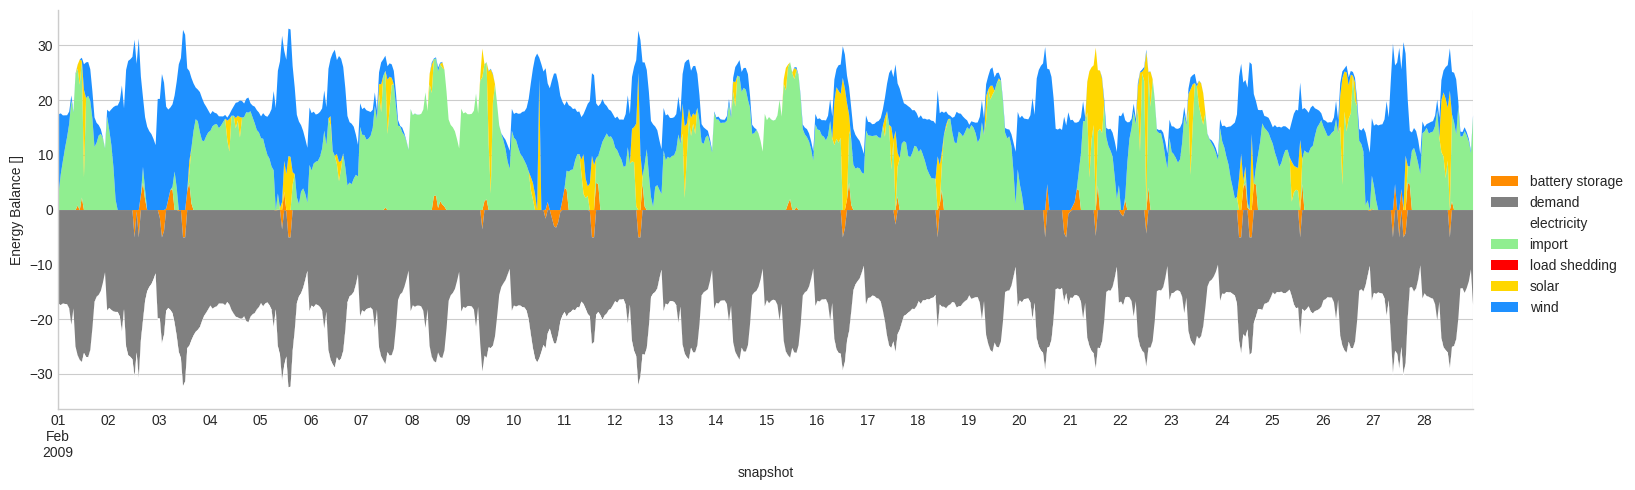

In [53]:
# Energy balances plot as time series (in MW):
sum(ts.e_load_mw)
n.statistics.energy_balance.plot.area(linewidth=0, bus_carrier="electricity",figsize=(15,5))
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

<Axes: xlabel='snapshot'>

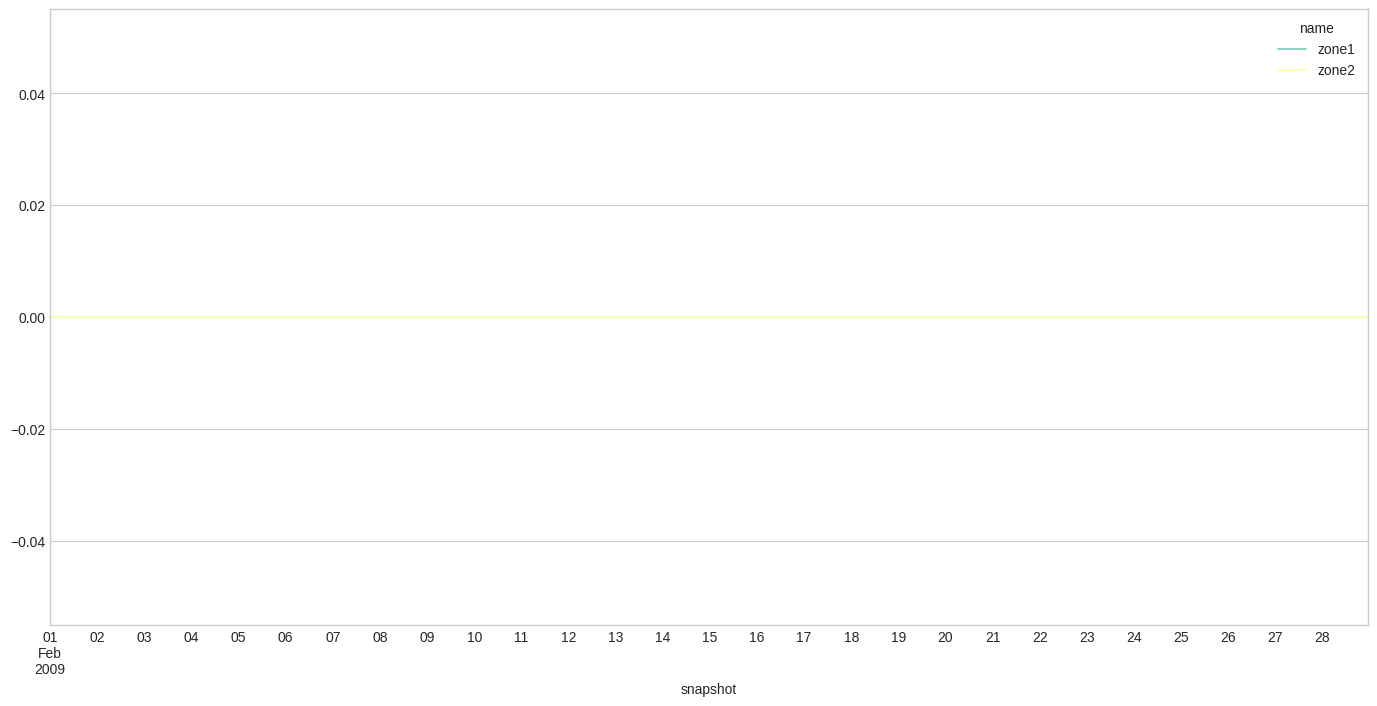

In [54]:
# Price time series for electricity:
n.buses_t.marginal_price.plot(figsize=(17, 8))

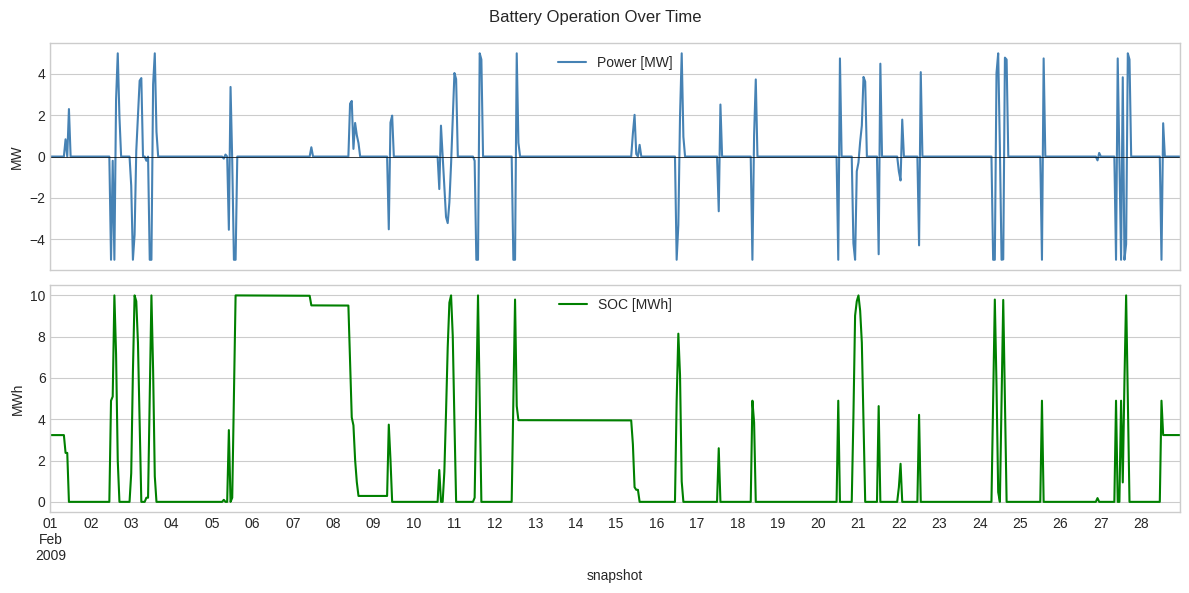

In [55]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Charge / discharge power
# n.storage_units_t.p["battery storage zone 2"].plot(
n.storage_units_t.p["battery storage zone 1"].plot(
    ax=axes[0], label="Power [MW]", color="steelblue"
)
axes[0].set_ylabel("MW")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].legend()
axes[0].grid(True)

# Zone 2 SOC
# n.storage_units_t.state_of_charge["battery storage zone 2"].plot(
n.storage_units_t.state_of_charge["battery storage zone 1"].plot(
    ax=axes[1], label="SOC [MWh]", color="green"
)
axes[1].set_ylabel("MWh")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Battery Operation Over Time")
plt.tight_layout()
plt.show()

#### System Costs - Scenario C

Total system cost: €9.922M/year
Total system cost: €826799.28/month


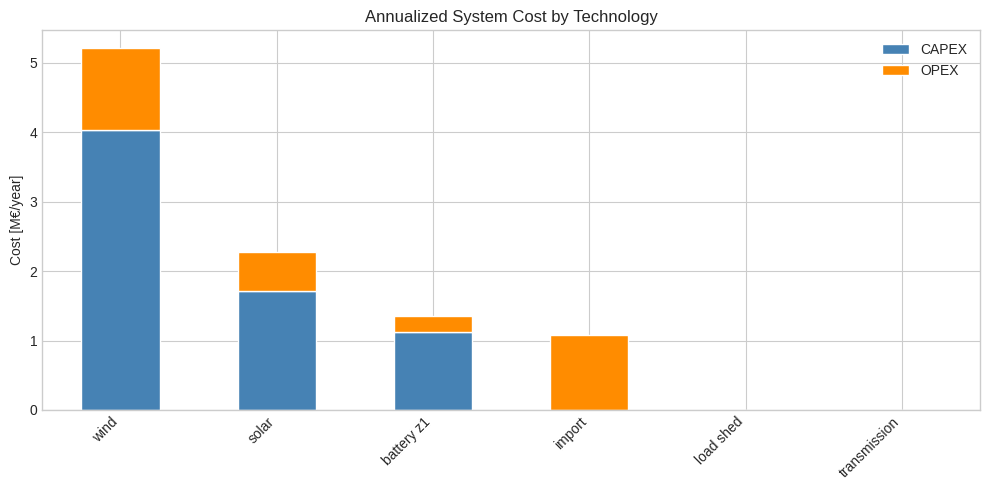

In [56]:
# Costs Reconstruction
# Reconstruct costs manually
opt_wind_mw = n.generators.p_nom_opt["wind"]
opt_solar_mw = n.generators.p_nom_opt["solar"]
opt_battery_z1_mw = n.storage_units.p_nom_opt["battery storage zone 1"]
# opt_battery_z2_mw = n.storage_units.p_nom_opt["battery storage zone 2"]
opt_import_mwh = n.generators_t.p["import"].sum()
opt_loadshed_mwh = n.generators_t.p["load shedding"].sum()

cost_data = {
    "wind":       {"CAPEX": annualized_capex_wind * opt_wind_mw,
                   "OPEX":  annualized_opex_wind  * opt_wind_mw},
    "solar":      {"CAPEX": annualized_capex_solar * opt_solar_mw,
                   "OPEX":  annualized_opex_solar  * opt_solar_mw},
    "battery z1": {"CAPEX": annualized_capex_battery * opt_battery_z1_mw,
                   "OPEX":  annualized_opex_battery  * opt_battery_z1_mw},
    # "battery z2": {"CAPEX": annualized_capex_battery * opt_battery_z2_mw,
    #                "OPEX":  annualized_opex_battery  * opt_battery_z2_mw},
    "import":     {"CAPEX": 0,
                   "OPEX":  Operational_cost_electricity_import_cost * opt_import_mwh},
    "load shed":  {"CAPEX": 0,
                   "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_mwh},
    "transmission": {"CAPEX": annualized_capex_transmission * n.links.loc["zone1-zone2", "p_nom"],
                     "OPEX":  annualized_opex_transmission  * n.links.loc["zone1-zone2", "p_nom"]},
}

cost_df = pd.DataFrame(cost_data).T.div(1e6)  # convert to M€

# plot
print(f"Total system cost: €{cost_df['CAPEX'].sum() + cost_df['OPEX'].sum():.3f}M/year")
total_annual_cost = cost_df['CAPEX'].sum() + cost_df['OPEX'].sum()
total_monthly_cost = total_annual_cost * 1e6/ 12
print(f"Total system cost: €{total_monthly_cost:.2f}/month")
fig, ax = plt.subplots(figsize=(10, 5))
cost_df[["CAPEX", "OPEX"]].plot(kind="bar", stacked=True, ax=ax,
                                 color=["steelblue", "darkorange"])
ax.set_ylabel("Cost [M€/year]")
ax.set_title("Annualized System Cost by Technology")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Curtailment - Scenario C

Total curtailment: 991.6 MWh
Wind curtailment: 767.5 MWh
Solar curtailment: 224.0 MWh


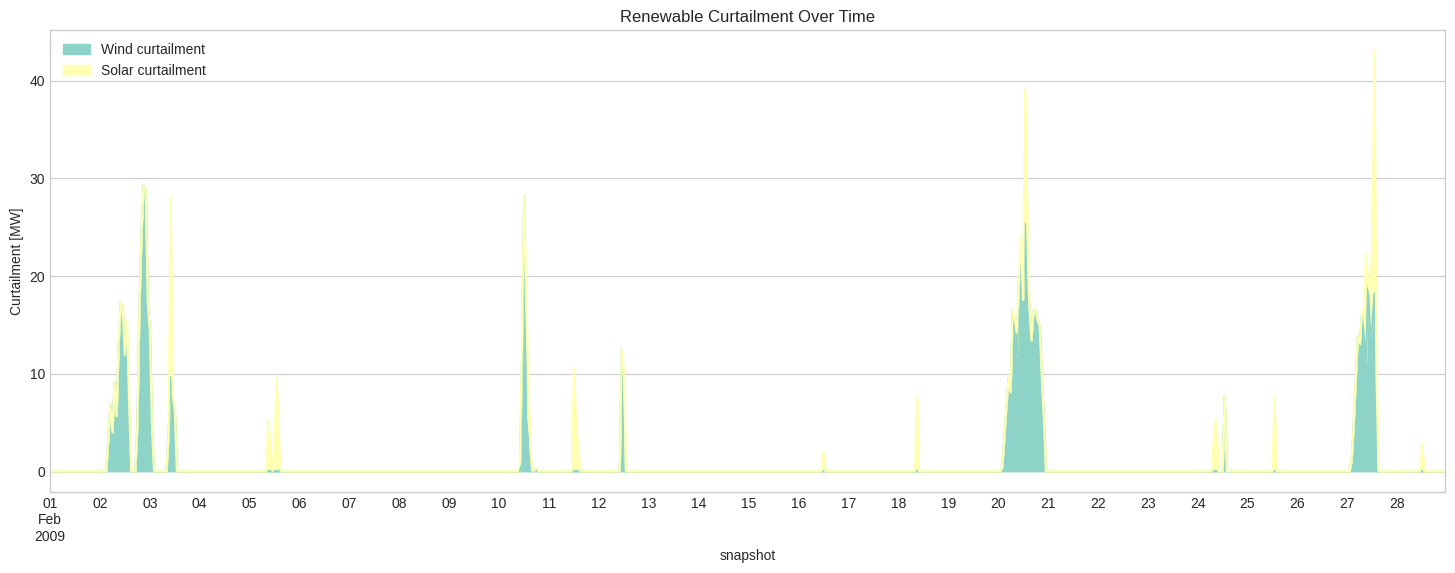

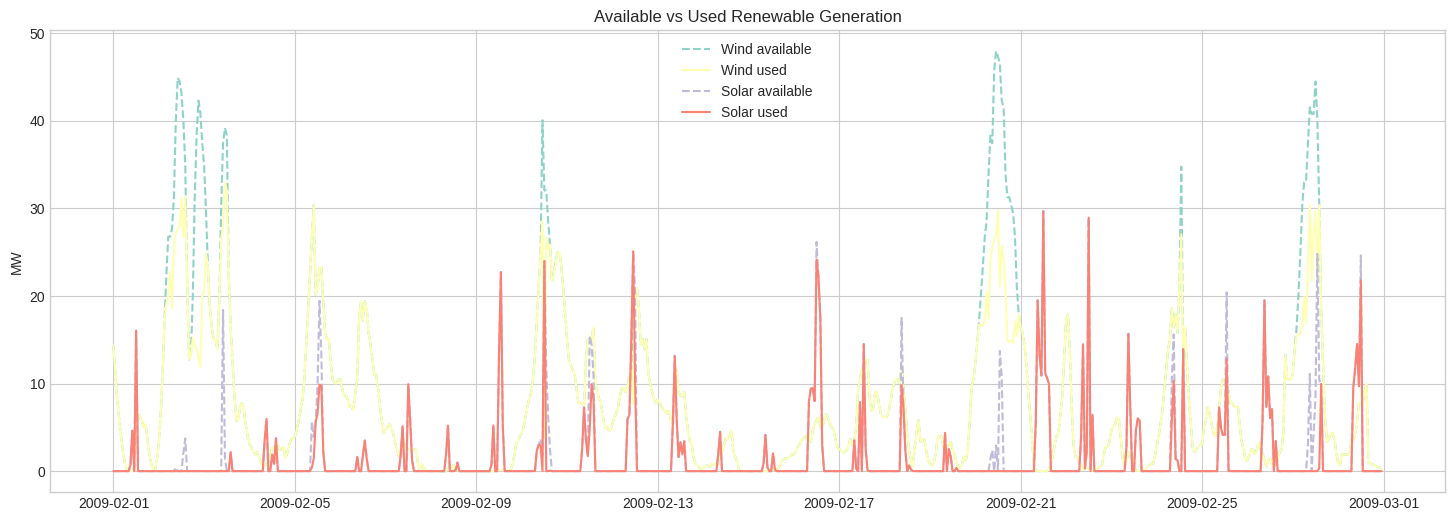

In [57]:
# Available generation (MW)
opt_wind_mw = n.generators.p_nom_opt["wind"] * n.generators_t.p_max_pu["wind"]
opt_solar_mw = n.generators.p_nom_opt["solar"] * n.generators_t.p_max_pu["solar"]

# Actual generation (MW)
gen_wind = n.generators_t.p["wind"]
gen_solar = n.generators_t.p["solar"]

# Curtailment (MW)
curtailment_wind = opt_wind_mw - gen_wind
curtailment_solar = opt_solar_mw - gen_solar

# Clean numerical noise
curtailment_wind = curtailment_wind.clip(lower=0)
curtailment_solar = curtailment_solar.clip(lower=0)

total_curtailment = (curtailment_wind + curtailment_solar).sum()

print(f"Total curtailment: {total_curtailment:.1f} MWh")
print(f"Wind curtailment: {curtailment_wind.sum():.1f} MWh")
print(f"Solar curtailment: {curtailment_solar.sum():.1f} MWh")

curtailment_df = pd.DataFrame({
    "Wind curtailment": curtailment_wind,
    "Solar curtailment": curtailment_solar
})

curtailment_df.plot.area(figsize=(18,6))
plt.ylabel("Curtailment [MW]")
plt.title("Renewable Curtailment Over Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(18,6))

plt.plot(opt_wind_mw, label="Wind available", linestyle="--")
plt.plot(gen_wind, label="Wind used")

plt.plot(opt_solar_mw, label="Solar available", linestyle="--")
plt.plot(gen_solar, label="Solar used")

plt.legend()
plt.title("Available vs Used Renewable Generation")
plt.ylabel("MW")
plt.grid(True)
plt.show()

#### Transmission - Scenario C

30.0
Optimized capacity: 30.0 MW
Max flow used: 29.1 MW
30.0
Average utilization: 28.87%
Max utilization: 97.09%
Congested hours: 0


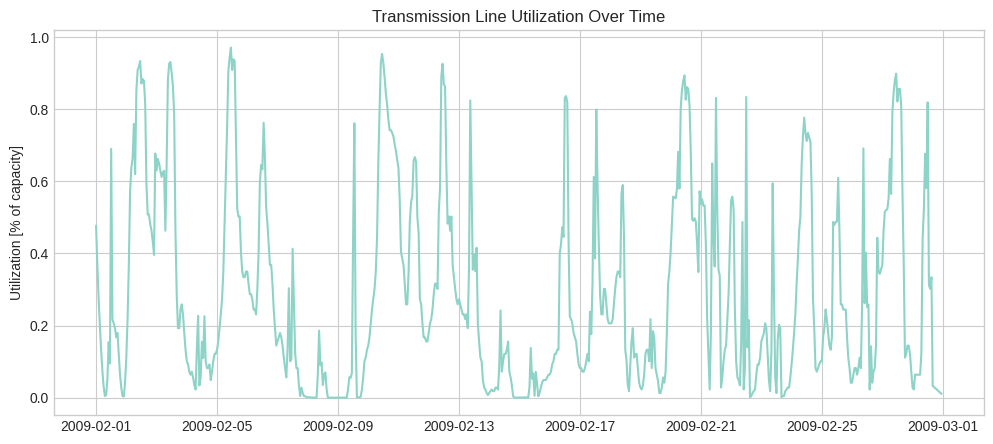

In [58]:
# post allowing transmission building
opt_line_capacity = n.links.p_nom_opt["zone1-zone2"]

#pre-freedom to build
opt_flow = n.links_t.p0["zone1-zone2"]
# opt_line_capacity = n.links.loc["zone1-zone2", "p_nom"]
utilization = opt_flow.abs() / opt_line_capacity
avg_util = utilization.mean()
max_util = utilization.max()
congested_hours = (utilization > 0.99).sum()

print(n.links.p_nom_opt["zone1-zone2"])
print(f"Optimized capacity: {opt_line_capacity} MW")
print(f"Max flow used: {opt_flow.abs().max():.1f} MW")

print(opt_line_capacity)
print(f"Average utilization: {avg_util:.2%}")
print(f"Max utilization: {max_util:.2%}")
print(f"Congested hours: {congested_hours}")

plt.figure(figsize=(12,5))
plt.plot(utilization)
plt.ylabel("Utilization [% of capacity]")
plt.title("Transmission Line Utilization Over Time")
plt.grid(True)
plt.show()

#### Unserved Demand - Scenario C

In [59]:
unserved_mwh = n.generators_t.p["load shedding"].sum()

print(f"Total unserved demand: {unserved_mwh:.1f} MWh")

Total unserved demand: 0.0 MWh


# Comparison Section
In the cells below we compare multiple scenarios across the following KPIs
- Total System Cost

### System Cost Comparision

In [ ]:
def build_cost_df(n, annualized_capex_wind, annualized_opex_wind,
                      annualized_capex_solar, annualized_opex_solar,
                      annualized_capex_battery, annualized_opex_battery,
                      annualized_capex_transmission, annualized_opex_transmission,
                      Operational_cost_electricity_import_cost,
                      Operational_cost_lost_load_penalty):

    opt_wind_mw      = n.generators.p_nom_opt.get("wind", 0)
    opt_solar_mw     = n.generators.p_nom_opt.get("solar", 0)
    opt_battery_z1_mw = n.storage_units.p_nom_opt.get("battery storage zone 1", 0)
    opt_import_mwh   = n.generators_t.p.get("import", pd.Series(dtype=float)).sum()
    opt_loadshed_mwh = n.generators_t.p.get("load shedding", pd.Series(dtype=float)).sum()

    cost_data = {
        "wind":         {"CAPEX": annualized_capex_wind  * opt_wind_mw,
                         "OPEX":  annualized_opex_wind   * opt_wind_mw},
        "solar":        {"CAPEX": annualized_capex_solar * opt_solar_mw,
                         "OPEX":  annualized_opex_solar  * opt_solar_mw},
        "battery z1":   {"CAPEX": annualized_capex_battery * opt_battery_z1_mw,
                         "OPEX":  annualized_opex_battery  * opt_battery_z1_mw},
        "import":       {"CAPEX": 0,
                         "OPEX":  Operational_cost_electricity_import_cost * opt_import_mwh},
        "load shed":    {"CAPEX": 0,
                         "OPEX":  Operational_cost_lost_load_penalty * opt_loadshed_mwh},
        "transmission": {"CAPEX": annualized_capex_transmission * n.links.loc["zone1-zone2", "p_nom"],
                         "OPEX":  annualized_opex_transmission  * n.links.loc["zone1-zone2", "p_nom"]},
    }

    return pd.DataFrame(cost_data).T.div(1e6)  # M€


# ── Cost parameters (shared across scenarios) ─────────────────────────────────
cost_params = dict(
    annualized_capex_wind=annualized_capex_wind,
    annualized_opex_wind=annualized_opex_wind,
    annualized_capex_solar=annualized_capex_solar,
    annualized_opex_solar=annualized_opex_solar,
    annualized_capex_battery=annualized_capex_battery,
    annualized_opex_battery=annualized_opex_battery,
    annualized_capex_transmission=annualized_capex_transmission,
    annualized_opex_transmission=annualized_opex_transmission,
    Operational_cost_electricity_import_cost=Operational_cost_electricity_import_cost,
    Operational_cost_lost_load_penalty=Operational_cost_lost_load_penalty,
)

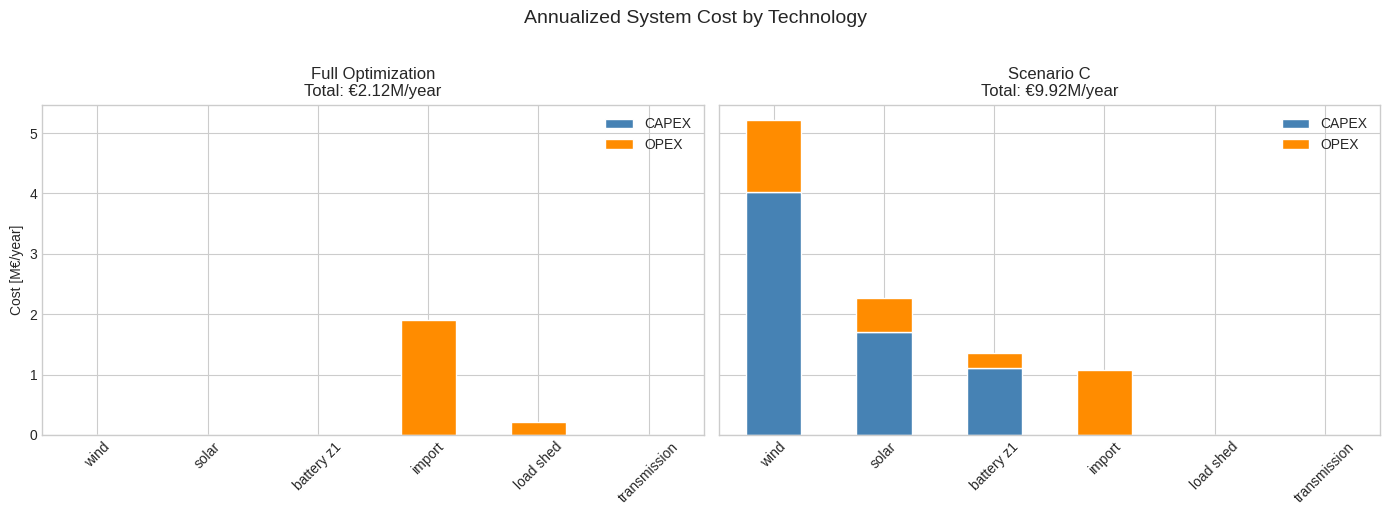

In [63]:
# ── Plot one stacked bar per scenario ─────────────────────────────────────────
fig, axes = plt.subplots(1, len(networks), figsize=(7 * len(networks), 5), sharey=True)

for ax, (label, n) in zip(axes, networks.items()):
    cost_df = build_cost_df(n, **cost_params)
    total   = cost_df["CAPEX"].sum() + cost_df["OPEX"].sum()

    cost_df[["CAPEX", "OPEX"]].plot(kind="bar", stacked=True, ax=ax,
                                     color=["steelblue", "darkorange"])
    ax.set_title(f"{label}\nTotal: €{total:.2f}M/year")
    ax.set_ylabel("Cost [M€/year]")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Annualized System Cost by Technology", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks


                   Wind [MW]  Solar [MW]  Battery [MW]  Line [MW]  \
Full Optimization       -0.0         0.0           0.0        0.0   
Scenario C              50.0        50.0          10.0       30.0   

                   Import [MWh]  Load shed [MWh]  Total cost [M€/y]  \
Full Optimization  12731.039759       140.860077           2.120946   
Scenario C          7207.955339         0.000000          10.518771   

                   Wind curtailment [hours]  Solar curtailment [hours]  \
Full Optimization                  0.000000                   0.000000   
Scenario C                       767.529841                 224.041046   

                   Total curtailment [hours]  
Full Optimization                   0.000000  
Scenario C                        991.570887  


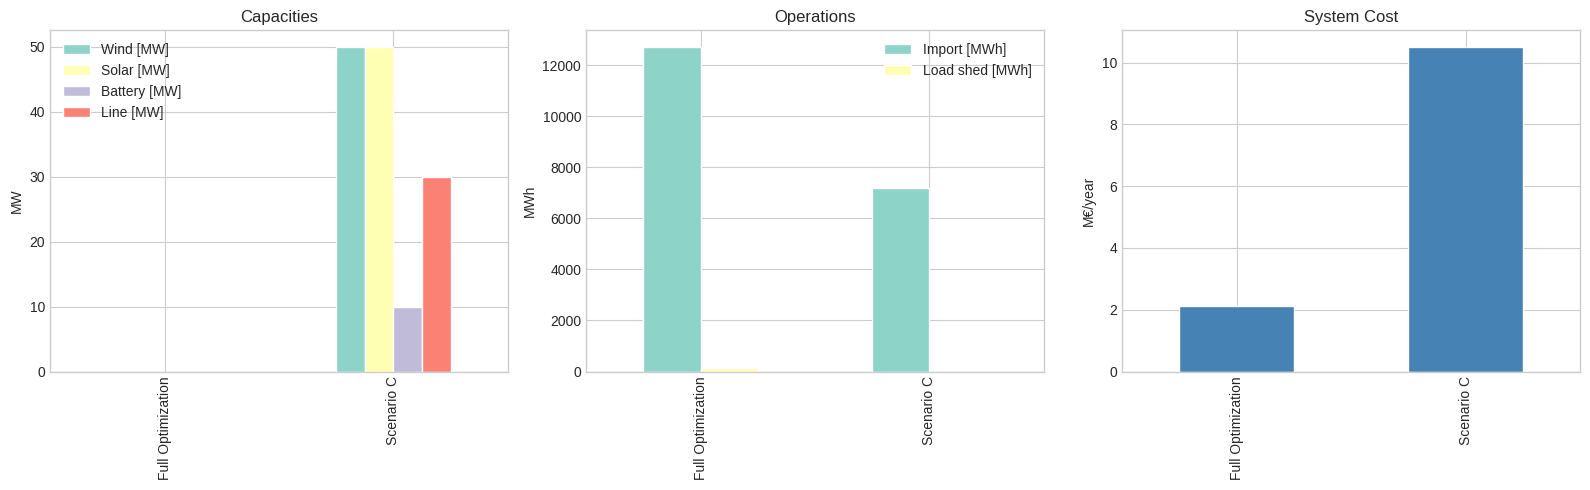

In [61]:
# ── 1. Run / load each scenario ───────────────────────────────────────────────
# Option A: if you already have solved networks saved as netCDF
networks = {
    "Full Optimization": pypsa.Network("results/full_opt.nc"),
    "Scenario C": pypsa.Network("results/scenario_C.nc"),
}

# ── 2. Extract KPIs from each network ─────────────────────────────────────────
def extract_kpis(n, label):
    opt_wind     = n.generators.p_nom_opt.get("wind", 0)
    opt_solar    = n.generators.p_nom_opt.get("solar", 0)
    opt_batt     = n.storage_units.p_nom_opt.sum()
    opt_line     = n.links.p_nom_opt.get("zone1-zone2", n.links.p_nom.get("zone1-zone2", 0))

    import_mwh   = n.generators_t.p.get("import", pd.Series(0)).sum()
    loadshed_mwh = n.generators_t.p.get("load shedding", pd.Series(0)).sum()

    #curtailment
    opt_wind_mw = n.generators.p_nom_opt["wind"] * n.generators_t.p_max_pu["wind"]
    opt_solar_mw = n.generators.p_nom_opt["solar"] * n.generators_t.p_max_pu["solar"]
    gen_wind = n.generators_t.p["wind"]
    gen_solar = n.generators_t.p["solar"]
    curtailment_wind = opt_wind_mw - gen_wind
    curtailment_solar = opt_solar_mw - gen_solar
    curtailment_wind = curtailment_wind.clip(lower=0).sum()
    curtailment_solar = curtailment_solar.clip(lower=0).sum()
    total_curtailment = (curtailment_wind + curtailment_solar).sum()

    total_cost = (
        pd.concat([n.statistics.capex(), n.statistics.opex()], axis=1)
        .sum(axis=1).sum() / 1e6          # M€/year
    )

    return {
        "Wind [MW]":        opt_wind,
        "Solar [MW]":       opt_solar,
        "Battery [MW]":     opt_batt,
        "Line [MW]":        opt_line,
        "Import [MWh]":     import_mwh,
        "Load shed [MWh]":  loadshed_mwh,
        "Total cost [M€/y]": total_cost,
        "Wind curtailment [hours]": curtailment_wind,
        "Solar curtailment [hours]": curtailment_solar,
        "Total curtailment [hours]": total_curtailment,
    }

kpis = pd.DataFrame(
    {label: extract_kpis(n, label) for label, n in networks.items()}
)
print(kpis.T)

# ── 3. Side-by-side bar charts ────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

kpis.loc[["Wind [MW]", "Solar [MW]", "Battery [MW]", "Line [MW]"]].T \
    .plot(kind="bar", ax=axes[0]); axes[0].set_title("Capacities"); axes[0].set_ylabel("MW")

kpis.loc[["Import [MWh]", "Load shed [MWh]"]].T \
    .plot(kind="bar", ax=axes[1]); axes[1].set_title("Operations"); axes[1].set_ylabel("MWh")

kpis.loc[["Total cost [M€/y]"]].T \
    .plot(kind="bar", ax=axes[2], legend=False, color="steelblue")
axes[2].set_title("System Cost"); axes[2].set_ylabel("M€/year")

plt.tight_layout(); plt.show()

### Curtailment

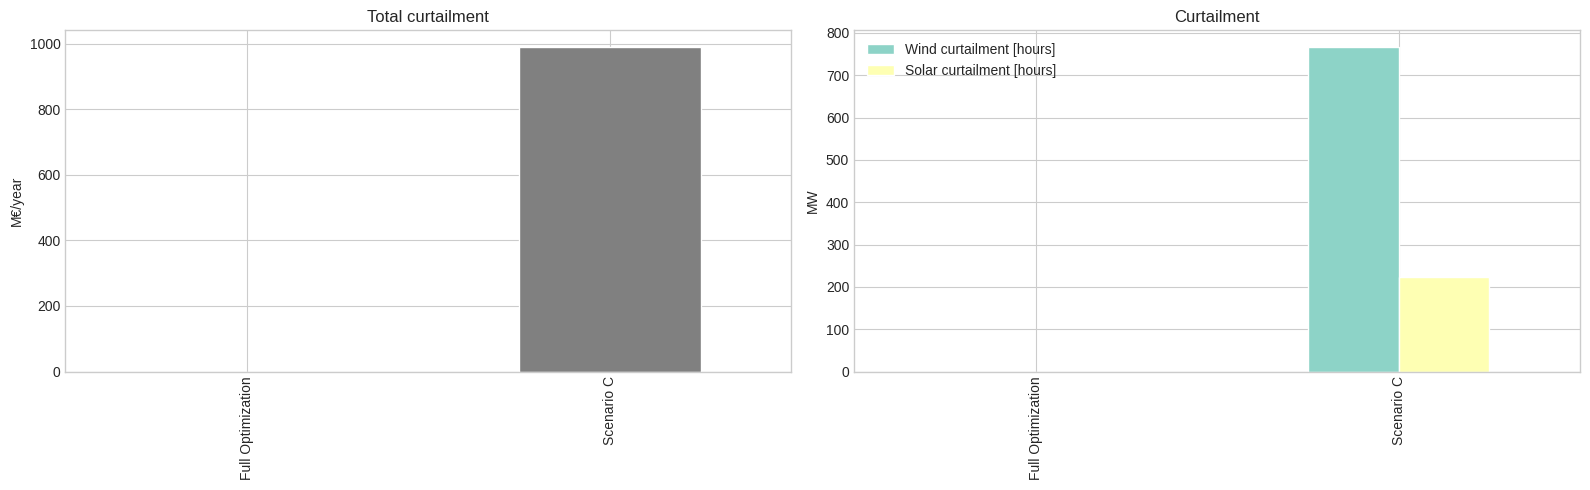

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

kpis.loc[["Total curtailment [hours]"]].T \
    .plot(kind="bar", ax=axes[0], legend=False, color="grey")
axes[0].set_title("Total curtailment"); axes[0].set_ylabel("M€/year")

kpis.loc[["Wind curtailment [hours]", "Solar curtailment [hours]"]].T \
    .plot(kind="bar", ax=axes[1]); axes[1].set_title("Curtailment"); axes[1].set_ylabel("MW")

plt.tight_layout(); plt.show()

### Winning Scenario

(<Figure size 1643x500 with 1 Axes>,
 <Axes: xlabel='snapshot', ylabel='Energy Balance []'>,
 <seaborn.axisgrid.FacetGrid at 0x730b30759bd0>)

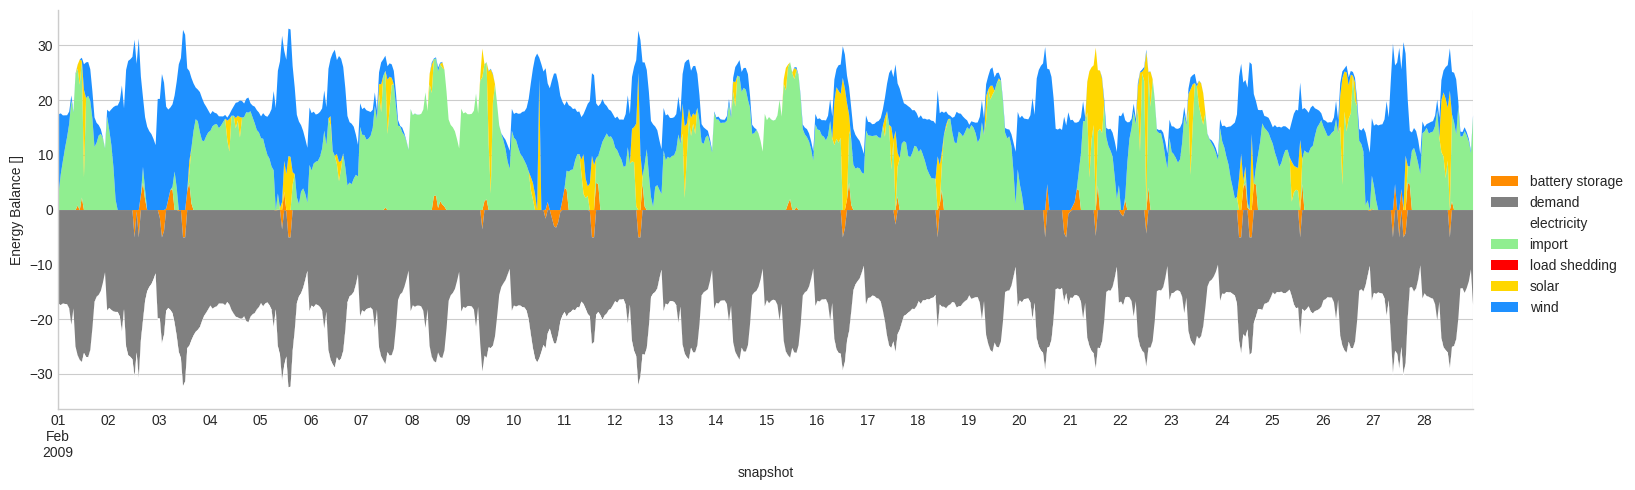

In [64]:
#energy balance
n.statistics.energy_balance.plot.area(
    bus_carrier="electricity",
    linewidth=0,
    figsize=(15, 5)
)